# Taking a look at the fault data
starting off with the underhang bearing fault with 35g mass attached


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random


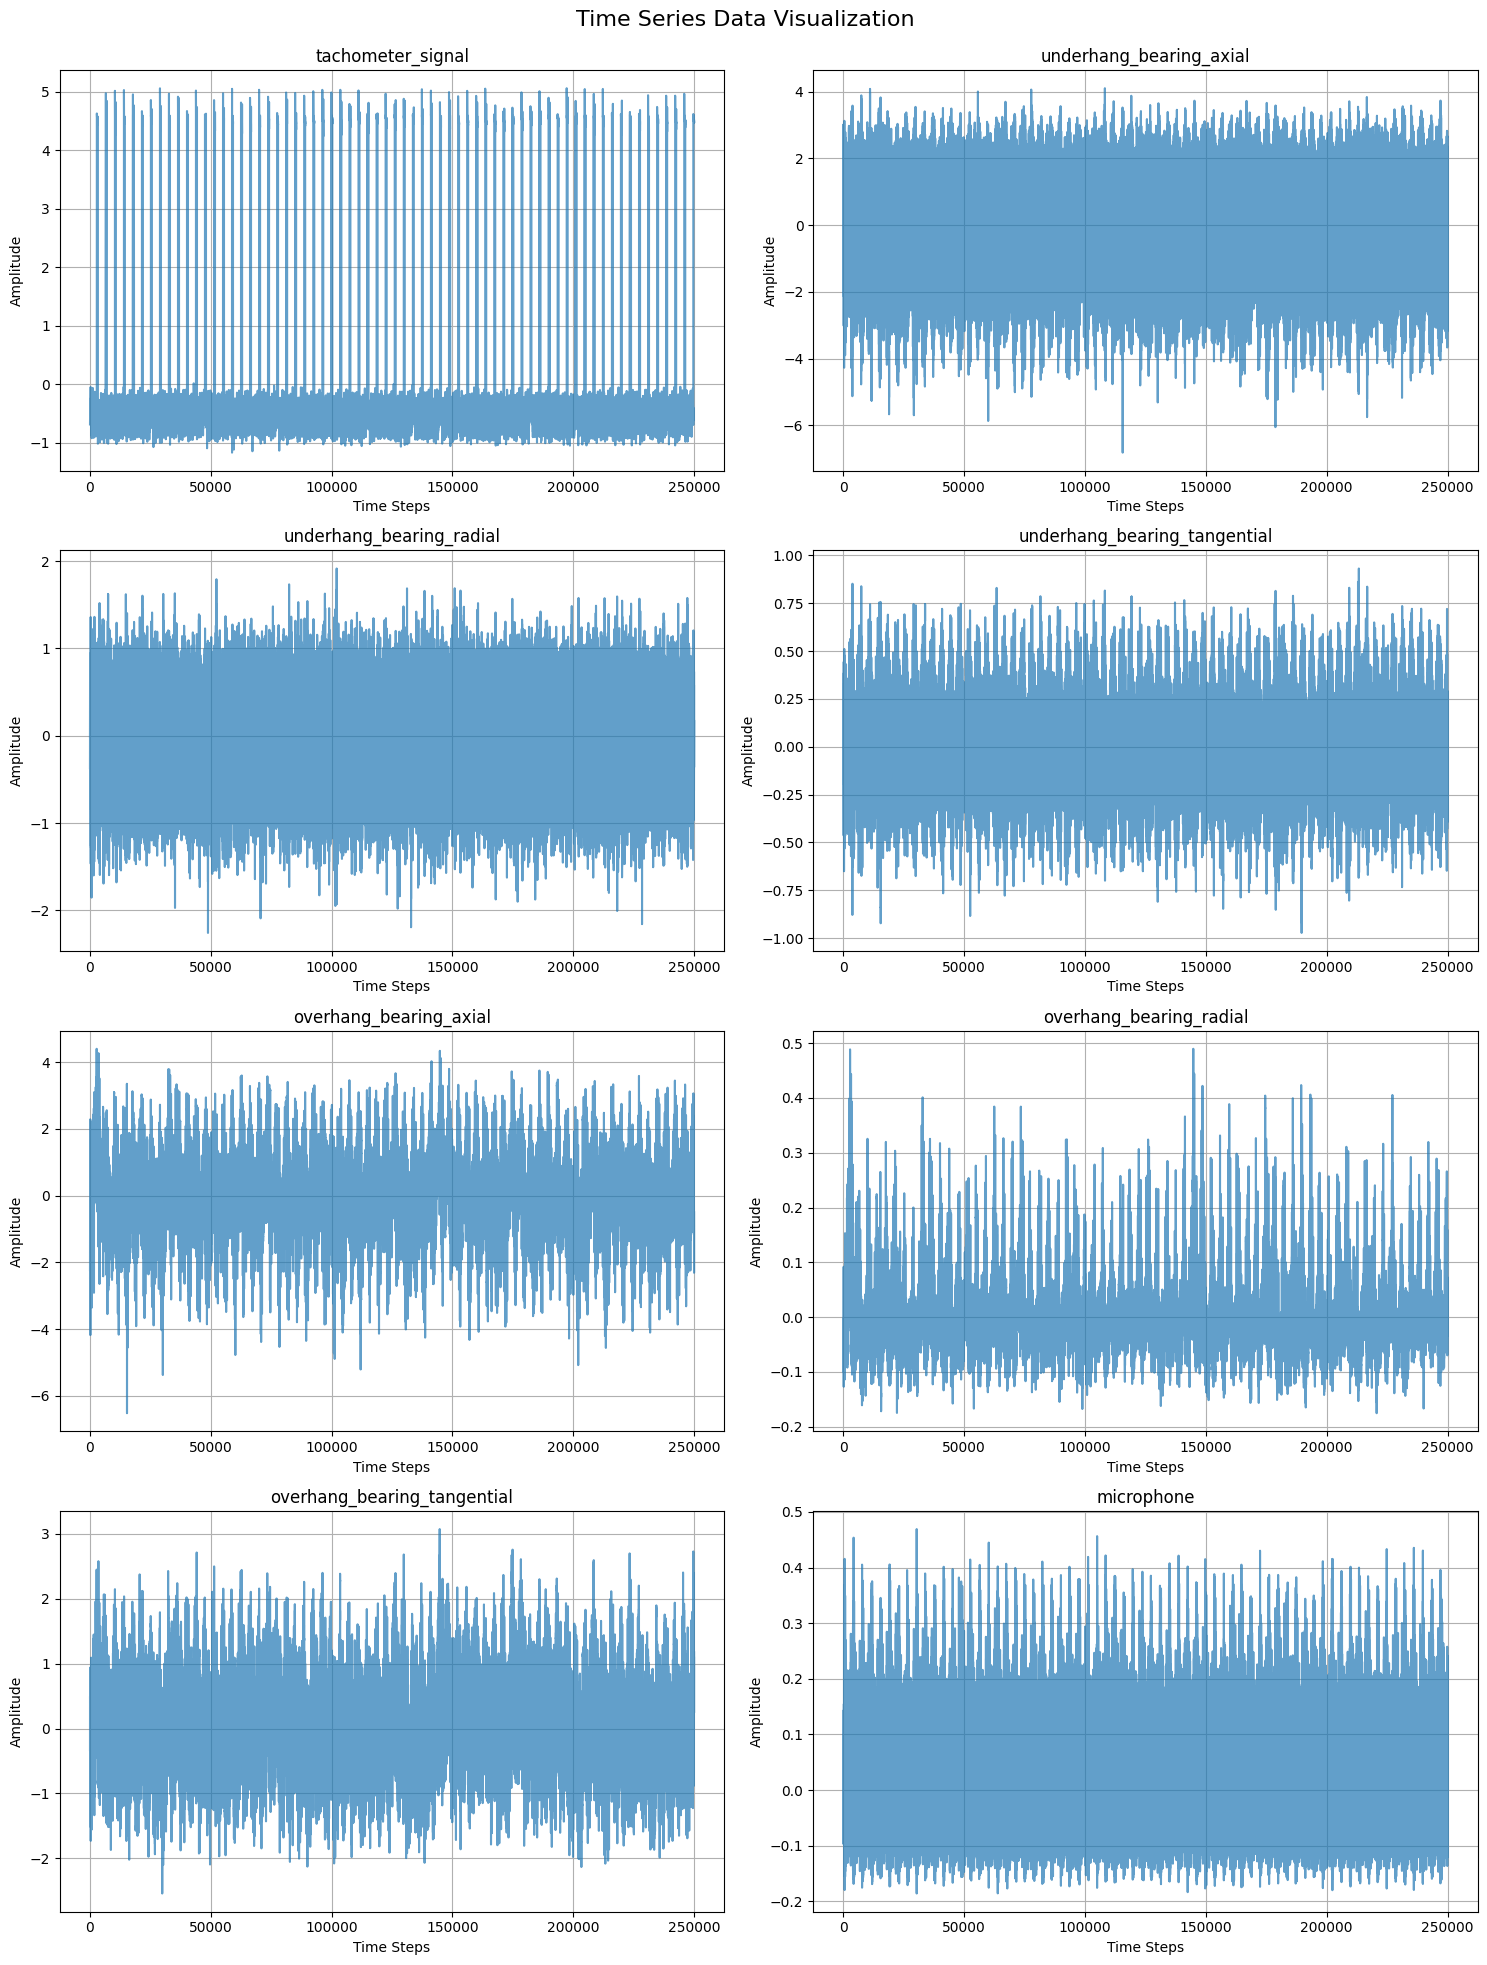

In [2]:
column_names = [
    'tachometer_signal',  # Column 1
    'underhang_bearing_axial', 'underhang_bearing_radial', 'underhang_bearing_tangential',  # Columns 2 to 4
    'overhang_bearing_axial', 'overhang_bearing_radial', 'overhang_bearing_tangential',  # Columns 5 to 7
    'microphone'  # Column 8
]

# Load CSV file into a DataFrame
df = pd.read_csv('./data/fault/underhang_35g_bearing/50kHz/13.7216.csv', header=None) # 12.288 is the first sequence (lowest rpm)
df_last = pd.read_csv('./data/fault/underhang_35g_bearing/50kHz/50.7904.csv', header=None) # 61.44 is the last sequence (highest rpm) 

df.columns = column_names
df_last.columns = column_names

# Create subplots for each column
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.suptitle('Time Series Data Visualization', fontsize=16)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each column
for idx, column in enumerate(df.columns):
    axes[idx].plot(df[column], alpha=0.7)
    axes[idx].set_title(f'{column}')
    axes[idx].set_xlabel('Time Steps')
    axes[idx].set_ylabel('Amplitude')
    axes[idx].grid(True)

# Remove empty subplot if number of columns is odd
if len(df.columns) < len(axes):
    fig.delaxes(axes[-1])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.95)


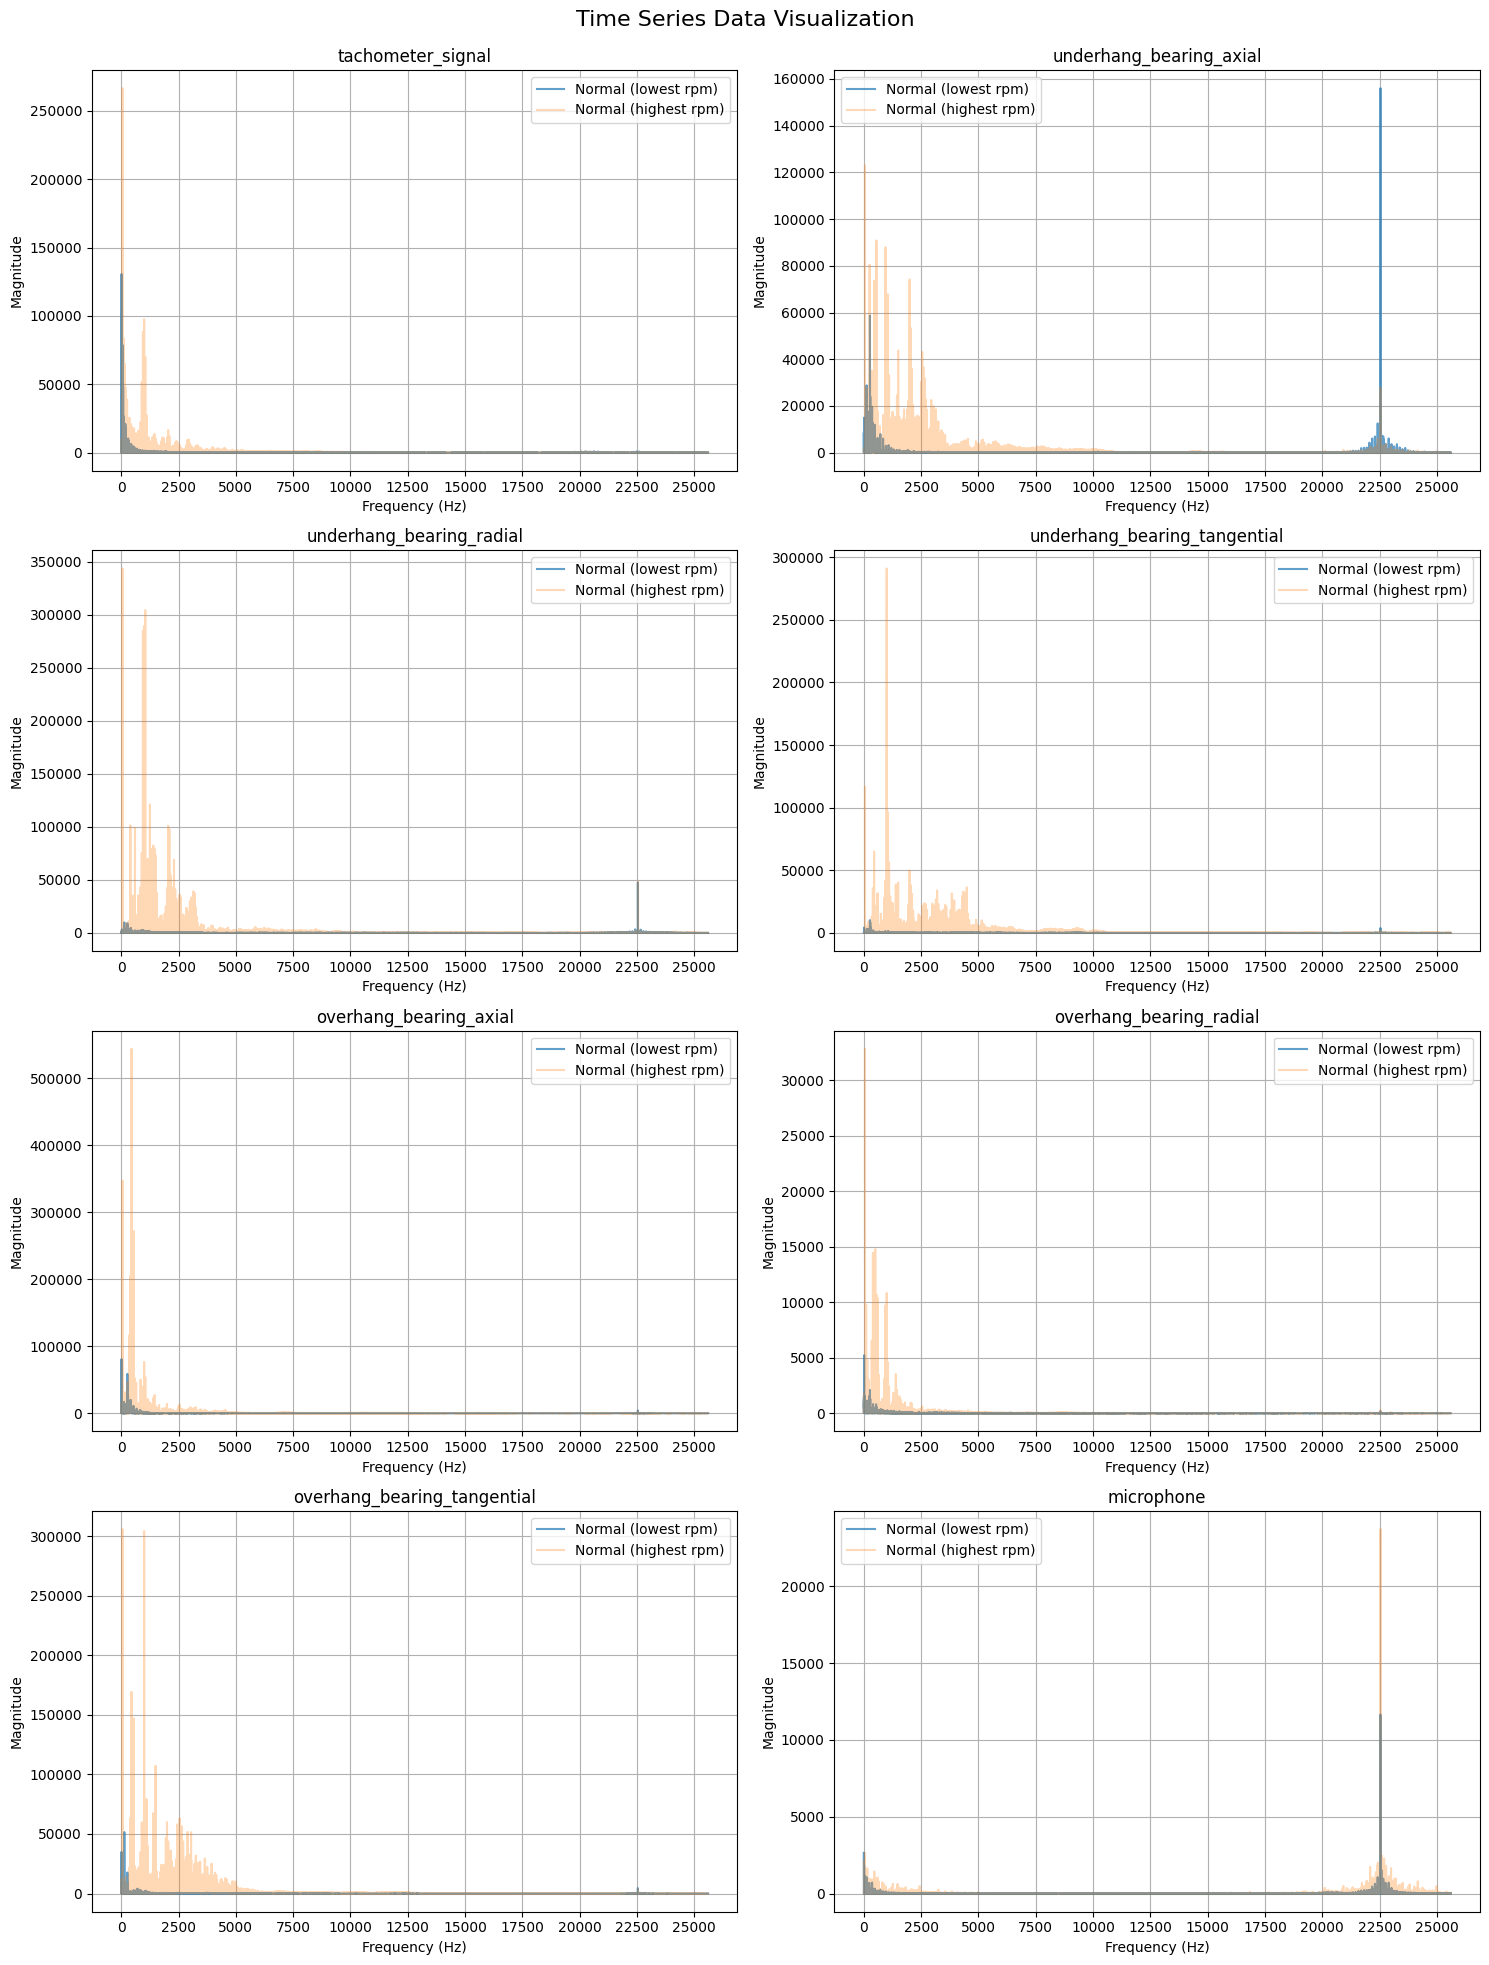

In [4]:
f = 51200 # Hz sampling frequency
T = 1/f # Sampling period

# Create subplots for each column
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.suptitle('Time Series Data Visualization', fontsize=16)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each column
for idx, column in enumerate(df.columns):
    fourier = np.fft.fft(df[column])
    fourier_last = np.fft.fft(df_last[column])
    n = df[column].size
    n_last = df_last[column].size
    freq = np.fft.fftfreq(n, d=T)
    freq_last = np.fft.fftfreq(n_last, d=T) 
    axes[idx].plot(freq[:n//2], np.abs(fourier)[:n//2], alpha=0.7)
    axes[idx].plot(freq_last[:n_last//2], np.abs(fourier_last)[:n_last//2], alpha=0.3)
    axes[idx].set_title(f'{column}')
    axes[idx].set_xlabel('Frequency (Hz)')
    axes[idx].set_ylabel('Magnitude')
    axes[idx].grid(True)
    axes[idx].xaxis.set_major_locator(plt.MaxNLocator(12)) # Adjust 20 to desired number of ticks
    axes[idx].legend(['Normal (lowest rpm)', 'Normal (highest rpm)'])



# Remove empty subplot if number of columns is odd
if len(df.columns) < len(axes):
    fig.delaxes(axes[-1])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.95)

# Downsample fault data


In [10]:
def downsample_csv(name, current_freq, desired_freq):
    path = f'./data/fault/underhang_35g_bearing/50kHz/{name}'
    if os.path.isdir(path) or name.startswith('.'):
        return
    # Load CSV file into a DataFrame
    df = pd.read_csv(path, header=None)
    print(f'original size: {df.shape}')
    column_names = [
        'tachometer_signal',  # Column 1
        'underhang_bearing_axial', 'underhang_bearing_radial', 'underhang_bearing_tangential',  # Columns 2 to 4
        'overhang_bearing_axial', 'overhang_bearing_radial', 'overhang_bearing_tangential',  # Columns 5 to 7
        'microphone'  # Column 8
    ]
    df.columns = column_names
    ratio = int(current_freq/desired_freq)
    downsampled_df = df.iloc[::ratio]
    # print(downsampled_df.head())
    print(f'new size: {downsampled_df.shape}')
    downsampled_df.to_csv(f'./data/fault/underhang_35g_bearing/{desired_freq}Hz/{name}', index=False)

file_names = os.listdir('./data/fault/underhang_35g_bearing/50kHz')

for file in file_names:
    downsample_csv(file, 51200, 500)

original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size: (250000, 8)
new size: (2451, 8)
original size